In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings

warnings.filterwarnings("ignore")

In [3]:
DATA_PATH = "../data/raw/driver_risk.csv"

df = pd.read_csv(DATA_PATH, sep="\t")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (123, 14)


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Accident_Severity', 'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience', 'Road_Light_Condition', 'Accident']


In [5]:
df = df.dropna(how="all").reset_index(drop=True)

print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (123, 14)


In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (123, 14)


In [7]:
numerical_columns = [
    "Traffic_Density",
    "Speed_Limit",
    "Number_of_Vehicles",
    "Driver_Alcohol",
    "Driver_Age",
    "Driver_Experience",
    "Accident"
]

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
print("Missing target values:", df["Accident"].isna().sum())

Missing target values: 5


In [9]:
df = df.dropna(subset=["Accident"]).reset_index(drop=True)

df["Accident"] = df["Accident"].astype(int)

print("Target distribution:")
print(df["Accident"].value_counts())

Target distribution:
Accident
0    82
1    36
Name: count, dtype: int64


In [10]:
X = df.drop(columns=["Accident"])
y = df["Accident"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (118, 13)
y shape: (118,)


In [11]:
if "Accident_Severity" in X.columns:
    X = X.drop(columns=["Accident_Severity"])

print("Features used for prediction:")
print(X.columns.tolist())

Features used for prediction:
['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience', 'Road_Light_Condition']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (94, 12)
Testing set : (24, 12)


In [13]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience']

Categorical features:
['Weather', 'Road_Type', 'Time_of_Day', 'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition']


In [14]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [15]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [18]:
pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created:")
for name in pipelines:
    print("-", name)

Model pipelines created:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost


In [19]:
results = []

for model_name, pipeline in pipelines.items():

    print(f"Training {model_name}...")

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability predictions
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"{model_name} completed.")

Training Logistic Regression...
Logistic Regression completed.
Training KNN...
KNN completed.
Training Decision Tree...
Decision Tree completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
Training XGBoost...
XGBoost completed.


In [20]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.833333,0.800000,0.571429,0.666667,0.781513
1,XGBoost,0.791667,0.625000,0.714286,0.666667,0.773109
2,Gradient Boosting,0.750000,0.571429,0.571429,0.571429,0.739496
3,Decision Tree,0.750000,0.571429,0.571429,0.571429,0.697479
4,Random Forest,0.791667,0.750000,0.428571,0.545455,0.743697
5,KNN,0.666667,0.333333,0.142857,0.200000,0.537815


In [21]:
best_model_name = results_df.iloc[0]["Model"]

print("Best model based on F1 Score:")
print(best_model_name)

Best model based on F1 Score:
Logistic Regression


<Figure size 1200x600 with 0 Axes>

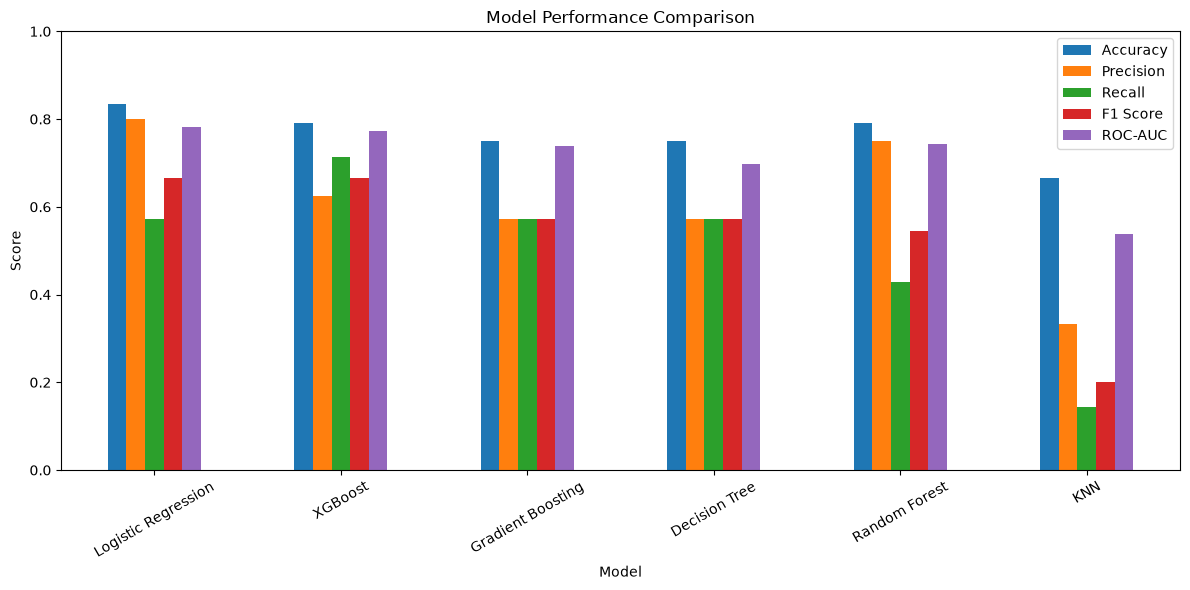

In [22]:
plt.figure(figsize=(12, 6))

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

plt.show()

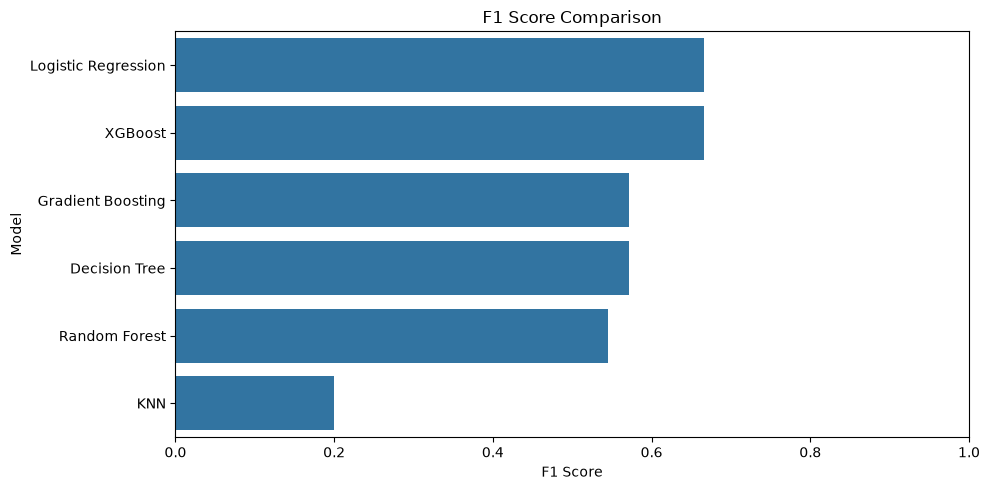

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title("F1 Score Comparison")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [24]:
best_pipeline = pipelines[best_model_name]

print("Best pipeline:")
print(best_pipeline)

Best pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Traffic_Density',
                                                   'Speed_Limit',
                                                   'Number_of_Vehicles',
                                                   'Driver_Alcohol',
                                                   'Driver_Age',
                                                   'Driver_Experience']),
                                                 ('categorical',
                                                  Pipeline(ste

In [25]:
best_predictions = best_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["No Accident", "Accident"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

 No Accident       0.84      0.94      0.89        17
    Accident       0.80      0.57      0.67         7

    accuracy                           0.83        24
   macro avg       0.82      0.76      0.78        24
weighted avg       0.83      0.83      0.82        24



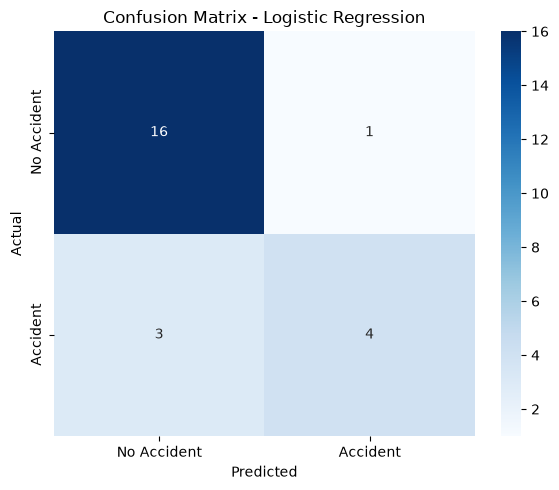

In [26]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Accident", "Accident"],
    yticklabels=["No Accident", "Accident"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

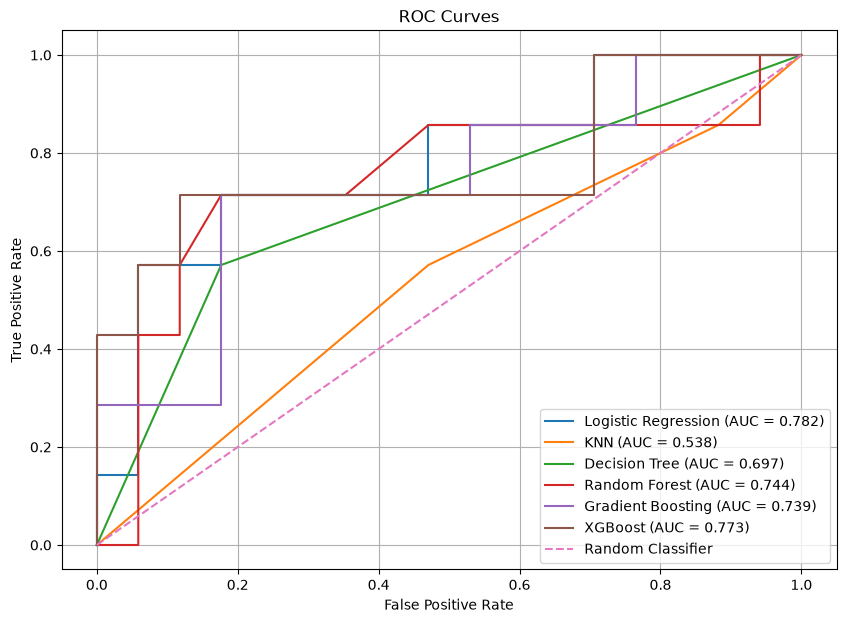

In [27]:
plt.figure(figsize=(10, 7))

for model_name, pipeline in pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [29]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/best_driver_risk_model.pkl"

joblib.dump(
    best_pipeline,
    model_path
)

print("Best pipeline saved to:")
print(model_path)

Best pipeline saved to:
../models/best_driver_risk_model.pkl
